<a href="https://colab.research.google.com/github/mim-1999/california-housing-regression/blob/main/notebooks/01_eda_and_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [36]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing(as_frame=True)

# Convert to dataframe
df = housing.frame

In [37]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [38]:
df.shape

(20640, 9)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [40]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [41]:
median_income = df['MedInc'].values

In [42]:
median_income_sorted = np.sort(median_income)

In [43]:
min_income = median_income_sorted.min()
max_income = median_income_sorted.max()
print(f"Minimum income is: {min_income:.4f}")
print(f"Maximum income is: {max_income:.4f}")

Minimum income is: 0.4999
Maximum income is: 15.0001


In [44]:
n = len(median_income)
Q1_index = int(0.25 * n)
Q3_index = int(0.75 * n)
Q1 = median_income_sorted[Q1_index]
Q3 = median_income_sorted[Q3_index]
print(f"Q1 is: {Q1:.4f}")
print(f"Q3 is: {Q3:.4f}")

Q1 is: 2.5637
Q3 is: 4.7437


In [45]:
median_position1 = int(0.5 * n)
median_position2 = int(0.5 * (n + 1))
median = (median_income_sorted[median_position1] + median_income_sorted[median_position2]) / 2
print(f"Median is:{median:.4f}")
print(f"Mean income is: {median_income_sorted.mean()}")

Median is:3.5349
Mean income is: 3.8706710029069766


In [46]:
IQR=Q3-Q1
print(f"IQR is: {IQR:.4f}")
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound is: {lower_bound:.4f}\nUpper bound is: {upper_bound:4f}")

IQR is: 2.1800
Lower bound is: -0.7063
Upper bound is: 8.013700


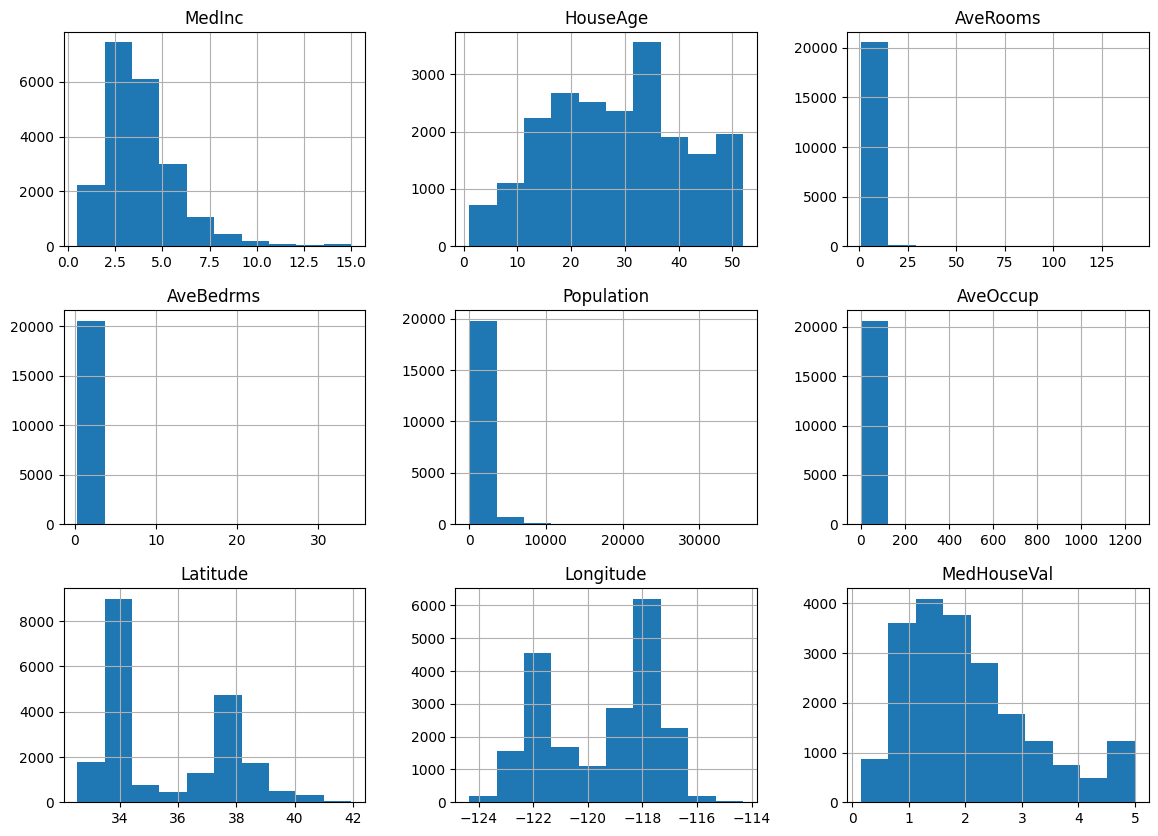

In [47]:
df.hist(figsize=(14,10))
plt.show()

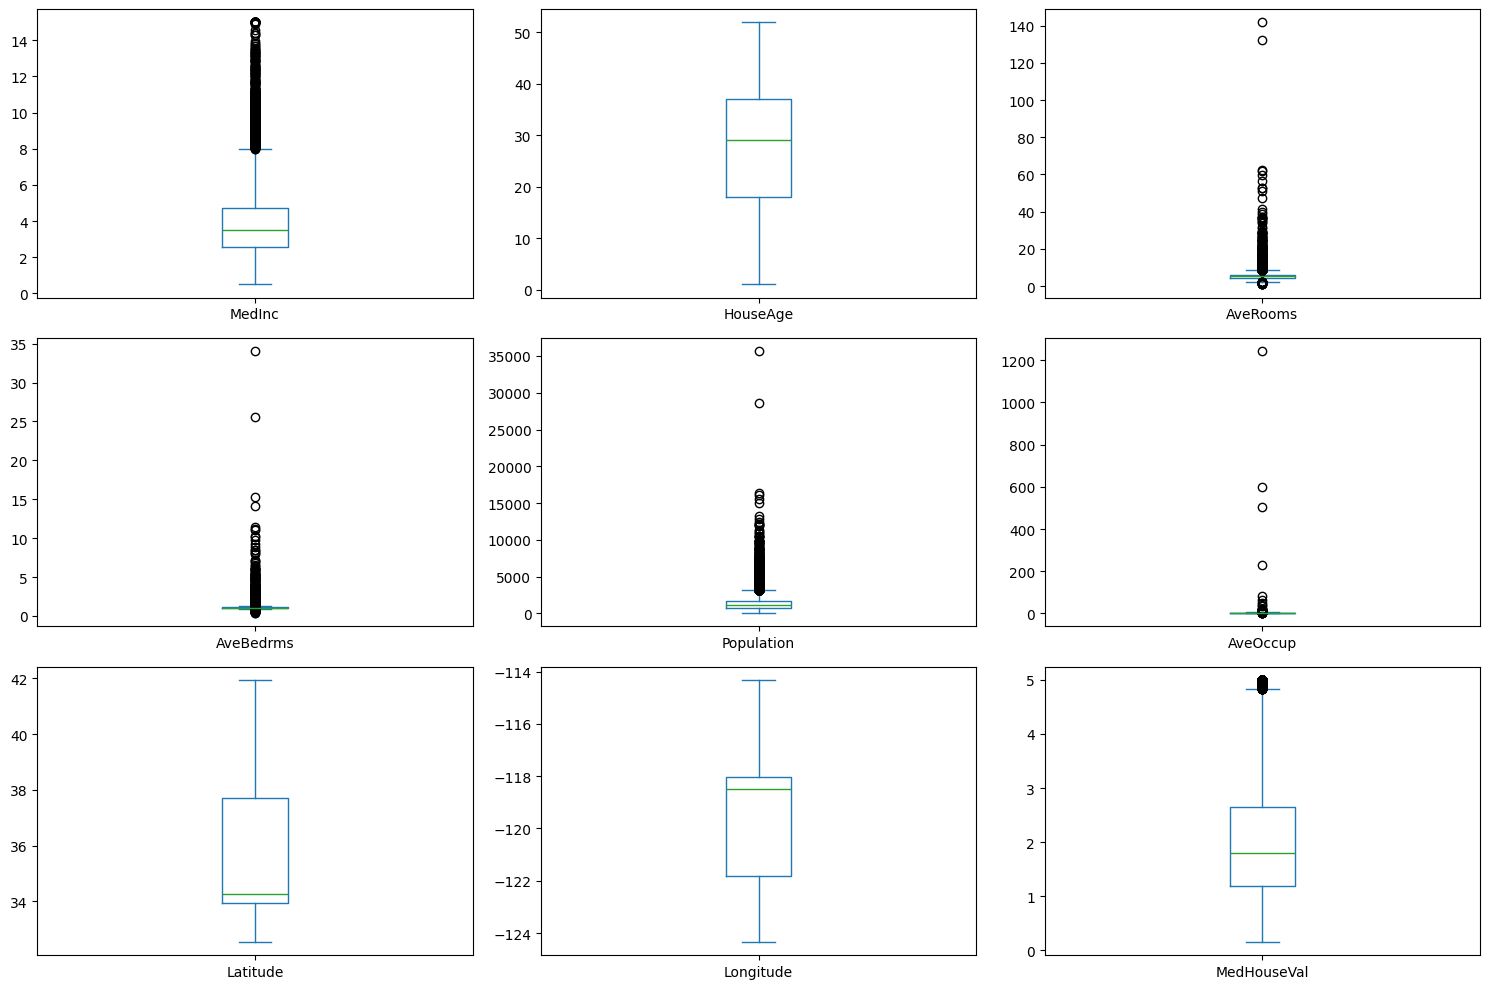

In [48]:
df.plot(
    kind="box",
    subplots=True,
    layout=(3,3),
    figsize=(15,10),
    sharex=False
)

plt.tight_layout()
plt.show()

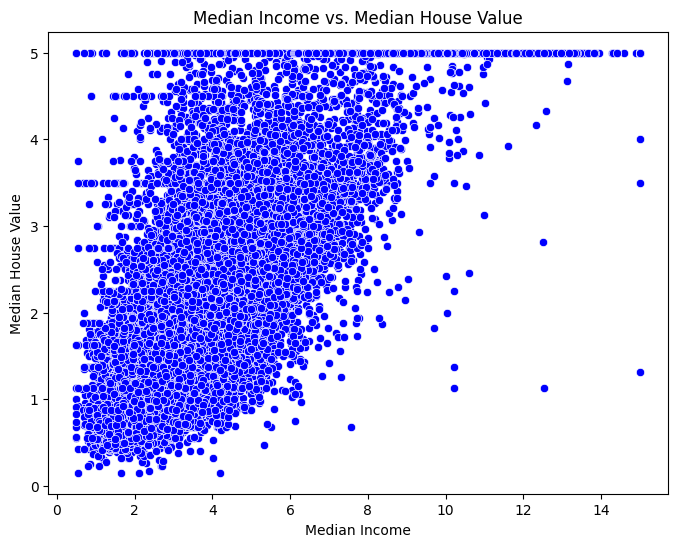

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="MedInc",
    y="MedHouseVal",
    data=df,
    color="blue"
)
plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

In [50]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


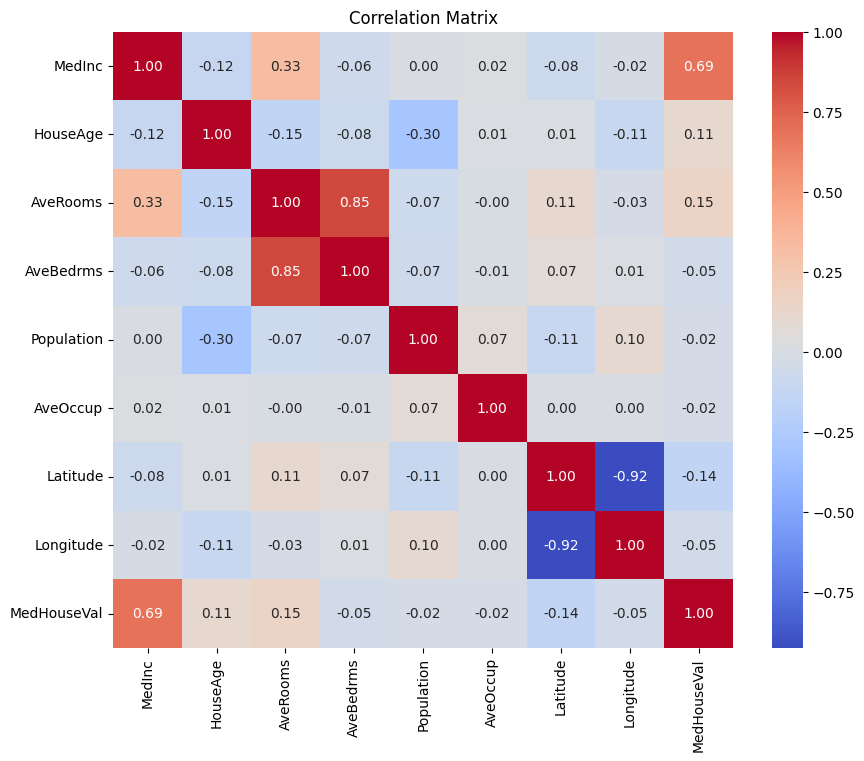

In [51]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [52]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [53]:
print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 8), (4128, 8), (16512,), (4128,))

In [56]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [57]:
y_pred = model.predict(X_test)

In [58]:
y_pred.shape

(4128,)

In [59]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.4f}")



R-squared score: 0.5758
Mean Absolute Error: 0.5332
Mean Squared Error: 0.5559
Root Mean Squared Error: 0.7456


In [60]:
residuals = y_test - y_pred
residuals.head()

,MedHouseVal
20046,-0.242123
3024,-1.306017
15663,2.290351
20484,-0.652926
9814,0.175343


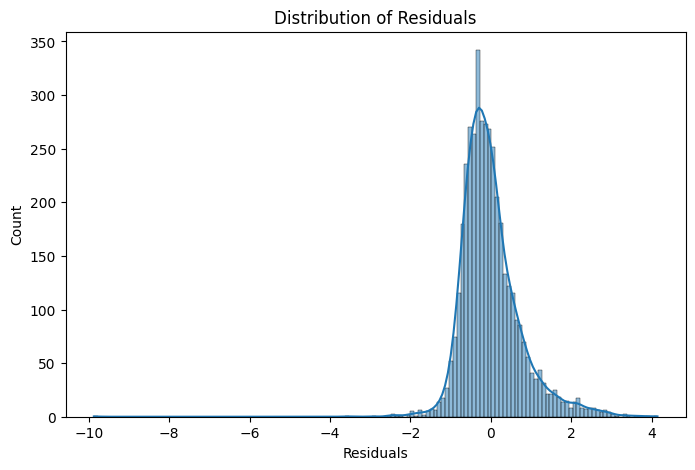

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Distribution of Residuals")

plt.show()

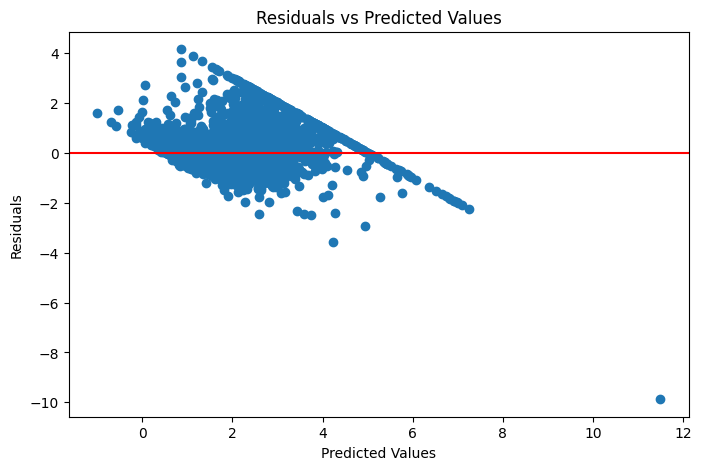

In [62]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

In [63]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [64]:
print(model.intercept_)
print(model.coef_)

-37.02327770606409
[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
